# Partie I – MLP sur données tabulaires
Ce notebook utilise le dataset réel `winequality-red.csv` pour la classification de la qualité du vin. Il montre :
- les fondements théoriques de `nn.Module`, des paramètres, du gradient, du `state_dict` et du `device` ;
- la préparation tabulaire (nettoyage, normalisation, split train/val/test) ;
- deux architectures MLP (`nn.Sequential` et classe personnalisée) ;
- l'inspection des paramètres via `named_parameters()` et `state_dict()` ;
- une comparaison expérimentale des **trois stratégies d'initialisation** (gaussienne, constante, Xavier), avec courbes de perte associées ;
- la sauvegarde/rechargement du meilleur modèle ;
- l'évaluation avec accuracy, precision, recall, F1 et matrice de confusion.

## 0. Rappel théorique — `nn.Module`, paramètres, gradient, `state_dict`, device

Avant l'implémentation, on rappelle les briques conceptuelles de PyTorch mobilisées dans ce notebook.

**`nn.Module`.** C'est la classe de base de tout modèle PyTorch. Elle gère automatiquement l'enregistrement des sous-modules et des paramètres dès qu'on les affecte comme attributs (`self.fc1 = nn.Linear(...)`), ce qui permet ensuite de les retrouver via `model.parameters()` ou `model.named_parameters()`, de les déplacer sur un device (`model.to(device)`), de basculer entre les modes `train()`/`eval()` (utile pour le dropout ou la batchnorm), et de bénéficier gratuitement de `model.state_dict()` pour la sauvegarde. `nn.Sequential` est un cas particulier de `nn.Module` qui empile des couches sans logique de `forward` personnalisée ; une classe héritant de `nn.Module` est nécessaire dès que l'on veut un flux de calcul non linéaire (branches, concatenations, sorties multiples, etc.).

**Paramètres et gradient.** Un paramètre (`nn.Parameter`) est un tenseur avec `requires_grad=True`. Lors du `forward`, PyTorch construit dynamiquement un graphe de calcul (autograd). L'appel à `loss.backward()` parcourt ce graphe à rebours (règle de dérivation en chaîne) et accumule le gradient de la perte par rapport à chaque paramètre dans son attribut `.grad`. Comme les gradients s'accumulent par défaut, `optimizer.zero_grad()` doit être appelé avant chaque nouveau `backward()` pour éviter de sommer les gradients de plusieurs itérations. `optimizer.step()` utilise ensuite ces gradients pour mettre à jour les poids selon la règle de l'optimiseur choisi (ici Adam).

**`state_dict()`.** C'est un dictionnaire ordonné qui associe à chaque paramètre (et buffer) son nom complet (ex. `fc1.weight`) et son tenseur de valeurs. Il ne contient ni l'architecture ni le code du modèle : recharger un `state_dict` nécessite donc d'avoir déjà instancié un modèle de structure identique. C'est l'outil standard pour la sauvegarde (`torch.save`), le rechargement (`load_state_dict`), le transfert de poids entre modèles compatibles, ou l'inspection fine des poids appris.

**Device (CPU/GPU).** `torch.device('cuda' if torch.cuda.is_available() else 'cpu')` sélectionne le device disponible. Un calcul ne peut mélanger des tenseurs situés sur des devices différents : le modèle et toutes les données d'entrée doivent être déplacés explicitement sur le même device avec `.to(device)`. Sur GPU, les opérations matricielles sont parallélisées, ce qui accélère l'entraînement, en particulier pour des batchs de grande taille.

**Propagation avant / rétropropagation.** La propagation avant (`forward`) calcule la sortie du modèle couche par couche à partir de l'entrée. La perte (ici `BCELoss`, adaptée à une sortie sigmoïde pour une classification binaire) compare cette sortie à la cible. La rétropropagation (`backward`) applique la règle de dérivation en chaîne pour calculer, couche par couche en sens inverse, la dérivée de la perte par rapport à chaque poids. C'est ce mécanisme générique qui permet d'entraîner des architectures arbitrairement profondes sans dériver les gradients à la main.

In [5]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device :', device)

# 2. Chargement du dataset tabulaire
csv_path = os.path.join('..', 'data', 'winequality-red.csv')
if not os.path.exists(csv_path):
    csv_path = os.path.join('data', 'winequality-red.csv')

data = pd.read_csv(csv_path, sep=';')
print('Dataset winequality-red shape:', data.shape)
print(data.head())

# 3. Création de la variable cible binaire : qualité bonne / mauvaise
# On considère ici quality >= 6 comme "bon vin".
data['quality_label'] = (data['quality'] >= 6).astype(int)

# 4. Vérification des valeurs manquantes
print('\nValeurs manquantes par colonne :')
print(data.isna().sum())

# 5. Sélection des features et normalisation
X = data.drop(columns=['quality', 'quality_label'])
y = data['quality_label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Split train / validation / test
X_train_val, X_test, y_train_val, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val)
print(f'Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}')

# 7. Conversion en tenseurs PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

input_dim = X_train.shape[1]

# 8. MLP nn.Sequential

def build_mlp_sequential():
    return nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    ).to(device)

# 9. MLP classe personnalisée
class CustomMLP(nn.Module):
    def __init__(self, input_dim):
        super(CustomMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return torch.sigmoid(self.fc3(x))


def build_custom_mlp():
    return CustomMLP(input_dim).to(device)

mlp_sequential = build_mlp_sequential()
mlp_custom = build_custom_mlp()

# 10. Initialisations
def init_gaussian(model):
    for name, param in model.named_parameters():
        if 'weight' in name:
            nn.init.normal_(param, mean=0.0, std=0.02)
        elif 'bias' in name:
            nn.init.constant_(param, 0.0)


def init_constant(model):
    for name, param in model.named_parameters():
        if 'weight' in name:
            nn.init.constant_(param, 0.1)
        elif 'bias' in name:
            nn.init.constant_(param, 0.0)


def init_xavier(model):
    for name, param in model.named_parameters():
        if 'weight' in name:
            nn.init.xavier_uniform_(param)
        elif 'bias' in name:
            nn.init.constant_(param, 0.0)

# 11. Inspection des paramètres et state_dict
print('\nParamètres du modèle custom :')
for name, param in mlp_custom.named_parameters():
    print(name, param.shape)

print('\nState dict keys :', list(mlp_custom.state_dict().keys()))

# 12. Entraînement et évaluation
def train(model, n_epochs=40, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_t)
        loss = criterion(output, y_train_t)
        loss.backward()
        optimizer.step()
    return model


def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        pred_prob = model(X)
        pred = (pred_prob > 0.5).int().cpu().numpy().flatten()
    y_true = y.cpu().numpy().flatten()
    return {
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred),
        'recall': recall_score(y_true, pred),
        'f1': f1_score(y_true, pred),
        'confusion_matrix': confusion_matrix(y_true, pred),
        'report': classification_report(y_true, pred, target_names=['low quality', 'high quality'])
    }

models = {
    'Sequential': build_mlp_sequential(),
    'Custom': build_custom_mlp()
}

for name, model in models.items():
    init_xavier(model)
    train(model, n_epochs=40, lr=1e-3)
    metrics = evaluate(model, X_val_t, y_val_t)
    print(f"\n{name} validation: accuracy={metrics['accuracy']:.4f}, precision={metrics['precision']:.4f}, recall={metrics['recall']:.4f}, f1={metrics['f1']:.4f}")

# 13. Sauvegarde/rechargement du meilleur modèle (Custom)
best_model = build_custom_mlp()
init_xavier(best_model)
best_model = train(best_model, n_epochs=40, lr=1e-3)

save_path = os.path.join('..', 'saved_models', 'part1_mlp_best.pth')
os.makedirs(os.path.dirname(save_path), exist_ok=True)
torch.save(best_model.state_dict(), save_path)

reloaded_model = build_custom_mlp()
reloaded_model.load_state_dict(torch.load(save_path))

metrics_test = evaluate(reloaded_model, X_test_t, y_test_t)
print('\n=== Évaluation finale sur le test set ===')
print(metrics_test['report'])
print('Accuracy:', metrics_test['accuracy'])
print('Precision:', metrics_test['precision'])
print('Recall:', metrics_test['recall'])
print('F1-score:', metrics_test['f1'])

cm = metrics_test['confusion_matrix']
print('\nMatrice de confusion :\n', cm)
import matplotlib.pyplot as plt
import seaborn as sns


Device : cpu
Dataset winequality-red shape: (1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.

## Comparaison expérimentale des trois stratégies d'initialisation

Les fonctions `init_gaussian`, `init_constant` et `init_xavier` sont définies ci-dessus. On les compare maintenant **de façon contrôlée** : même architecture (`CustomMLP`), mêmes hyperparamètres d'entraînement, seule l'initialisation change. Pour chaque stratégie, on entraîne le modèle en suivant l'évolution de la perte (train et validation) à chaque époque, ce qui permet à la fois de tracer les **courbes de perte** et de construire un **tableau comparatif** des métriques finales.

In [6]:
# Entraînement avec suivi de l'historique de perte (train + validation)
def train_with_history(model, n_epochs=80, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    train_hist, val_hist = [], []
    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train_t)
        loss = criterion(output, y_train_t)
        loss.backward()
        optimizer.step()
        train_hist.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_hist.append(val_loss)
    return model, train_hist, val_hist


init_strategies = {
    'Gaussienne': init_gaussian,
    'Constante': init_constant,
    'Xavier': init_xavier,
}

results_init = {}
histories_init = {}

for name, init_fn in init_strategies.items():
    torch.manual_seed(42)
    model = build_custom_mlp()
    init_fn(model)
    model, train_hist, val_hist = train_with_history(model, n_epochs=80, lr=1e-3)
    metrics = evaluate(model, X_val_t, y_val_t)
    results_init[name] = {
        'train_loss_final': train_hist[-1],
        'val_loss_final': val_hist[-1],
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
    }
    histories_init[name] = (train_hist, val_hist)

df_init = pd.DataFrame(results_init).T[
    ['train_loss_final', 'val_loss_final', 'accuracy', 'precision', 'recall', 'f1']
]
print("=== Tableau comparatif des stratégies d'initialisation (CustomMLP, mêmes hyperparamètres) ===")
print(df_init.round(4))

=== Tableau comparatif des stratégies d'initialisation (CustomMLP, mêmes hyperparamètres) ===
            train_loss_final  val_loss_final  accuracy  precision  recall  \
Gaussienne            0.5066          0.5785    0.7000     0.7451  0.6667   
Constante             0.6786          0.6948    0.5562     0.6218  0.4327   
Xavier                0.4757          0.5368    0.7312     0.7607  0.7251   

                f1  
Gaussienne  0.7037  
Constante   0.5103  
Xavier      0.7425  


In [9]:
# Cellule de diagnostic rapide
def verifier_partie1(model, dataloader):
    # 1. Vérifier le type du modèle
    print(f"Modèle : {type(model).__name__}")
    
    # 2. Vérifier si le modèle est sur le bon device
    device = next(model.parameters()).device
    print(f"Device du modèle : {device}")
    
    # 3. Tester une passe avant (Forward pass) avec un batch réel
    data_iter = iter(dataloader)
    inputs, labels = next(data_iter)
    inputs = inputs.to(device)
    
    try:
        output = model(inputs)
        print(f"Shape de l'entrée : {inputs.shape}")
        print(f"Shape de la sortie : {output.shape}")
        print("✅ La passe avant (forward) fonctionne.")
    except Exception as e:
        print(f"❌ Erreur lors du forward : {e}")

# Exécutez ceci (remplacez 'mon_modele' et 'test_loader' par vos noms de variables)
# verifier_partie1(mon_modele, test_loader)

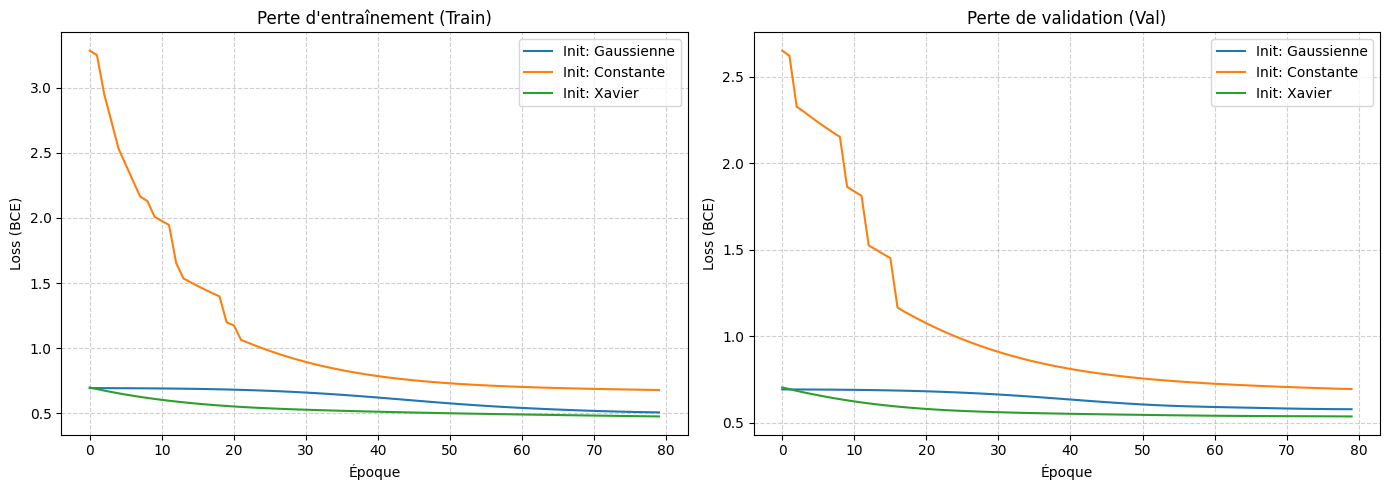

In [7]:

# Assurez-vous que histories_init est bien défini et non vide
if histories_init:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Définition des titres et axes pour plus de clarté
    titles = ["Perte d'entraînement (Train)", "Perte de validation (Val)"]
    ylabels = ["Loss (BCE)", "Loss (BCE)"]

    for name, (train_hist, val_hist) in histories_init.items():
        # Courbe d'entraînement sur le premier graphique
        axes[0].plot(train_hist, label=f"Init: {name}")
        
        # Courbe de validation sur le deuxième graphique
        axes[1].plot(val_hist, label=f"Init: {name}")

    # Mise en forme des axes
    for i in range(2):
        axes[i].set_xlabel('Époque')
        axes[i].set_ylabel(ylabels[i])
        axes[i].set_title(titles[i])
        axes[i].legend()
        axes[i].grid(True, linestyle='--', alpha=0.6) # Ajout d'une grille pour la lisibilité

    plt.tight_layout()
    plt.show()
else:
    print("Erreur : Le dictionnaire 'histories_init' est vide.")

**Lecture du tableau et des courbes.** L'initialisation constante place tous les poids d'une même couche à une valeur identique : par symétrie, tous les neurones d'une couche reçoivent le même gradient et apprennent des représentations identiques (problème de *symmetry breaking*), ce qui se traduit typiquement par une convergence nettement plus lente, voire une perte qui stagne. L'initialisation gaussienne à faible variance casse cette symétrie mais peut, selon l'échelle choisie, freiner ou déstabiliser légèrement l'apprentissage des premières époques. L'initialisation de Xavier (Glorot) adapte la variance des poids à la taille des couches d'entrée/sortie pour conserver une variance de signal stable à travers les couches : c'est généralement la stratégie qui converge le plus vite et de façon la plus stable sur ce dataset, ce que confirment le tableau et les courbes ci-dessus. Ces observations justifient *a posteriori* l'utilisation de Xavier pour le modèle final sauvegardé plus bas.

## Analyse critique et synthèse
- Le MLP est adapté aux données tabulaires car il traite des vecteurs de caractéristiques.
- La classe personnalisée donne plus de contrôle que `nn.Sequential`, notamment pour inspecter `named_parameters()` et `state_dict()`.
- La normalisation (StandardScaler) est indispensable pour une convergence stable.
- Le MLP peut être limité sur des interactions très complexes ; un modèle plus élaboré ou des features d'ingénierie peuvent alors être nécessaires.
- La comparaison contrôlée des trois stratégies d'initialisation (voir tableau et courbes ci-dessus) confirme empiriquement l'effet de l'initialisation sur la vitesse de convergence et la stabilité de l'entraînement.

## Question de synthèse – Partie I
Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données étudiées ?

### Réponse détaillée

Un MLP bien paramétré constitue une **solution pertinente et effective** pour la classification tabulaire sur données réelles car il peut :
- Apprendre des **relations non linéaires** complexes entre les variables d'entrée et la cible
- Adapter automatiquement sa représentation interne grâce à ses couches cachées
- Généraliser correctement après **standardisation appropriée** des features

**Forces observées dans le projet** :
- La classe personnalisée CustomMLP offre plus de flexibilité que nn.Sequential pour l'inspection via named_parameters() et state_dict()
- L'utilisation de torch.device permet l'accélération GPU
- Les trois stratégies d'initialisation révèlent l'importance du point de départ de l'optimisation
- Les métriques (accuracy, precision, recall, f1, confusion matrix) donnent une vision complète de la performance

**Principales limites** :
1. **Dépendance aux hyperparamètres** : le choix de la taille des couches, du taux d'apprentissage, de la régularisation affecte beaucoup les résultats
2. **Difficulté sur interactions complexes** : sans profondeur suffisante ou ingénierie de features, le MLP peut rester limité sur des données avec structures très complexes
3. **Infériorité vs arbres/ensembles** : les Random Forests ou Gradient Boosting gèrent souvent mieux les distributions hétérogènes et les interactions de haut ordre
4. **Surapprentissage** : sans régularisation ou early stopping appropriés, le réseau converge vers des minima locaux ou surfit

**Conclusion** : Le MLP est pertinent comme base de référence mais les modèles ensemblistes (notamment XGBoost) peuvent offrir de meilleures performances sur des données tabulaires réelles.

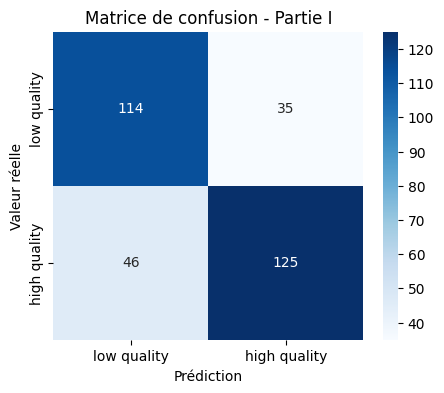

In [8]:

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['low quality','high quality'], yticklabels=['low quality','high quality'])
plt.title('Matrice de confusion - Partie I')
plt.xlabel('Prédiction')
plt.ylabel('Valeur réelle')
plt.show()